In [2]:
# ==========================================================
# CARGA DEL CONJUNTO DE DATOS
# ==========================================================

# Importamos la librería kagglehub para descargar datasets
# directamente desde Kaggle y trabajarlos con pandas.
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Indicamos el nombre del archivo que queremos cargar.
file_path = "diabetes_risk.csv"

# Descargamos y cargamos el dataset en un DataFrame de pandas.
# Este DataFrame será la estructura principal de trabajo.
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mansiaggarwal88/diabetes-risk-prediction",
    file_path
)

# Mostramos los primeros registros para verificar
# que los datos se cargaron correctamente.
print("Primeros 5 registros:")
print(df.head())

/tmp/ipykernel_5080/181619777.py:15: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'diabetes-risk-prediction' dataset.
Primeros 5 registros:
   patient_id  age  gender       city   bmi family_history_diabetes  \
0           1   47  Female     Mumbai  26.5                     Yes   
1           2   53  Female     Mumbai  20.5                     Yes   
2           3   47    Male      Thane  31.3                      No   
3           4   41    Male  Bengaluru  22.8                      No   
4           5   57  Female  Bengaluru  16.7                      No   

  physical_activity_level       diet_type smoking_status alcohol_consumption  \
0               Sedentary      Vegetarian          Never               Never   
1                Moderate      Vegetarian          Never               Never   
2                Moderate  Non-Vegetarian        Current             Regular   
3               Sedentary  Non-Vegetarian          Never               Never   
4               Sedentary  Non-Vegetarian        Current          Occasi

Se cargó el conjunto de datos diabetes_risk.csv desde Kaggle utilizando la librería KaggleHub. Este dataset contiene información relacionada con características demográficas, antecedentes familiares, hábitos de vida y variables médicas de los pacientes.

El objetivo del proyecto es analizar estos datos para identificar patrones asociados al riesgo de diabetes y posteriormente construir un modelo de minería de datos capaz de realizar predicciones sobre nuevos pacientes.

In [3]:
# ==========================================================
# VISUALIZACIÓN GENERAL DEL DATASET
# ==========================================================

# Mostramos el DataFrame completo.
# Esto permite observar las variables disponibles
# y verificar visualmente la estructura de los datos.
df

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High
14996,14997,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,NaN,Low
14997,14998,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low
14998,14999,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low


Se realizo una visualización general del conjunto de datos con el fin de identificar las variables disponibles y comprender la estructura de la información almacenada.

Esta revisión preliminar permite reconocer variables numéricas, categóricas y posibles inconsistencias antes de iniciar el análisis exploratorio.

In [4]:
# ==========================================================
# RADIODRAFÍA DEL CONJUNTO DE DATOS
# ==========================================================

# El método info() proporciona información sobre:
# - Número de registros
# - Número de columnas
# - Tipo de dato de cada variable
# - Cantidad de valores no nulos
# - Consumo de memoria

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

La función info() permite obtener una visión general de la estructura del dataset.

A través de este análisis se identifican:

Número total de registros.
Tipos de datos presentes.
Cantidad de valores disponibles por variable.
Existencia de posibles datos faltantes.

Esta información es fundamental para planificar las siguientes etapas de limpieza y transformación de datos.

In [5]:
# ==========================================================
# ESTADÍSTICA DESCRIPTIVA
# ==========================================================

# La función describe() calcula medidas estadísticas
# para todas las variables numéricas.

# Entre las métricas calculadas encontramos:
# - Media
# - Desviación estándar
# - Valor mínimo
# - Valor máximo
# - Cuartiles

df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


El conjunto de datos presenta 15 000 registros con pacientes de entre 18 y 80 años, siendo la edad promedio 44,33 años. El IMC (BMI) tiene un promedio de 23,06, mientras que la glucosa en ayunas presenta un promedio de 168,79 mg/dL y la hemoglobina glucosilada (HbA1c) un promedio de 6,88%, variables estrechamente relacionadas con el riesgo de diabetes.

Además, se observa variabilidad en indicadores como presión arterial y circunferencia de cintura, lo que sugiere la presencia de diferentes perfiles de riesgo dentro de la población analizada. En general, el dataset contiene información adecuada para desarrollar modelos predictivos orientados a la clasificación del riesgo de diabetes.

In [6]:
# ==========================================================
# DETECCIÓN DE VALORES NULOS
# ==========================================================

# Calculamos cuántos valores faltantes existen
# en cada variable del dataset.

df.isnull().sum()

,0
patient_id,0
age,0
gender,0
city,0
bmi,0
family_history_diabetes,0
physical_activity_level,0
diet_type,0
smoking_status,472
alcohol_consumption,3788


El análisis de valores nulos muestra que la mayoría de las variables del conjunto de datos están completas. Sin embargo, se identificaron 472 valores faltantes en la variable smoking_status, 3788 valores faltantes en alcohol_consumption y 463 valores faltantes en income_bracket.

La variable con mayor cantidad de datos faltantes es alcohol_consumption, por lo que será necesario aplicar técnicas de tratamiento de valores nulos durante la etapa de preprocesamiento. Las demás variables no presentan registros faltantes, lo que indica una buena calidad general de los datos para el desarrollo del modelo predictivo.

In [7]:
# ==========================================================
# IDENTIFICACIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

# Mostramos las categorías existentes en diabetes_risk
# para conocer qué tipo de predicción realizaremos.

print("Categorías encontradas:")
print(df["diabetes_risk"].unique())

# Mostramos cuántos registros existen en cada categoría.
print("\nCantidad de registros por categoría:")
print(df["diabetes_risk"].value_counts())

Categorías encontradas:
['Low' 'High' 'Moderate']

Cantidad de registros por categoría:
diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64


Identificación de la variable objetivo

La variable diabetes_risk será utilizada como variable objetivo (Y) debido a que representa el resultado que se desea predecir mediante técnicas de minería de datos. El análisis de sus categorías permitirá determinar si el problema corresponde a una clasificación binaria o multiclase y servirá como base para el entrenamiento de los modelos predictivos.

La variable diabetes_risk fue seleccionada como variable objetivo debido a que representa el nivel de riesgo de diabetes asociado a cada paciente. Se identificaron tres categorías: Low, Moderate y High, por lo que el problema corresponde a una clasificación multiclase.

La distribución de los registros muestra que la categoría Low concentra la mayor cantidad de observaciones con 9000 pacientes (60%), seguida de Moderate con 3750 pacientes (25%) y High con 2250 pacientes (15%). Esta distribución indica que existe un desbalance moderado entre las clases, aspecto que deberá considerarse durante la evaluación de los modelos predictivos.

El objetivo del proyecto será desarrollar un modelo capaz de clasificar a un paciente en uno de estos tres niveles de riesgo a partir de sus características médicas, hábitos de vida y antecedentes familiares.

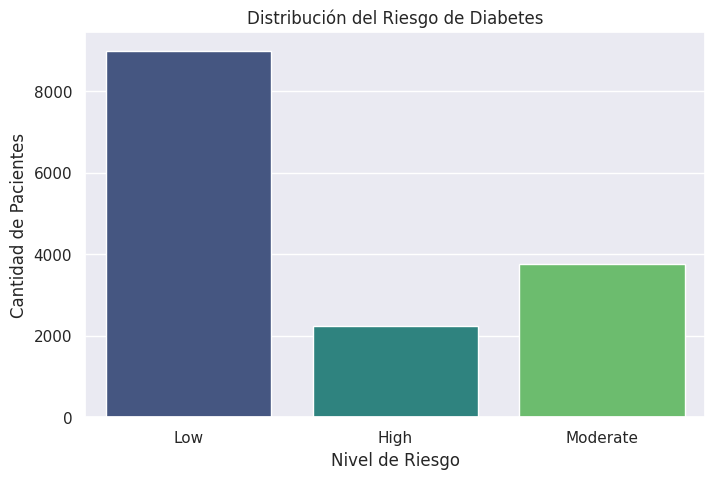

In [8]:
# ==========================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

# Importamos las librerías para visualización

import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo de los gráficos

sns.set_theme(style="darkgrid")

# Mostramos la cantidad de pacientes por cada
# categoría de riesgo de diabetes

plt.figure(figsize=(8,5))

sns.countplot(
data=df,
x="diabetes_risk",
hue="diabetes_risk",
palette="viridis",
legend=False
)

plt.title("Distribución del Riesgo de Diabetes")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Cantidad de Pacientes")

plt.show()

La gráfica muestra que la categoría Low es la más frecuente dentro del conjunto de datos, con aproximadamente 9000 registros, representando la mayoría de los pacientes. Por otro lado, la categoría Moderate cuenta con alrededor de 3750 registros, mientras que la categoría High presenta aproximadamente 2250 registros.

Esto indica que existe un desbalance moderado entre las clases, ya que los pacientes con riesgo bajo son considerablemente más numerosos que aquellos con riesgo moderado o alto. Este aspecto deberá considerarse durante la evaluación de los modelos predictivos para garantizar que el desempeño sea adecuado en todas las categorías y no únicamente en la clase mayoritaria.

Además, la presencia de tres categorías confirma que el problema corresponde a una clasificación multiclase, donde el objetivo será predecir si un paciente presenta un riesgo bajo, moderado o alto de desarrollar diabetes.

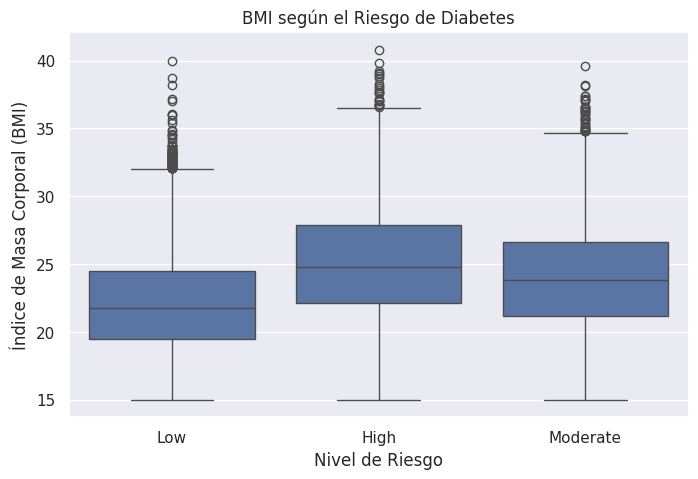

In [9]:
# ==========================================================
# BMI SEGÚN EL RIESGO DE DIABETES
# ==========================================================

# Analizamos cómo varía el índice de masa corporal
# en cada categoría de riesgo de diabetes.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="bmi"
)

plt.title("BMI según el Riesgo de Diabetes")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Índice de Masa Corporal (BMI)")

plt.show()

El diagrama de cajas muestra que los pacientes clasificados con riesgo alto (High) presentan, en general, valores de BMI más elevados que los pacientes de riesgo bajo (Low). La mediana del BMI en la categoría High es superior a la observada en las demás categorías, lo que sugiere una posible relación entre un mayor índice de masa corporal y un incremento en el riesgo de diabetes.

La categoría Moderate presenta valores intermedios, mientras que la categoría Low concentra los valores más bajos de BMI. Además, se observan algunos valores atípicos en las tres categorías, correspondientes a pacientes con índices de masa corporal considerablemente superiores al promedio.

En conjunto, la gráfica sugiere que el BMI podría ser una variable relevante para la predicción del riesgo de diabetes, ya que existe una tendencia a encontrar valores más altos de BMI en los pacientes clasificados con mayor riesgo.

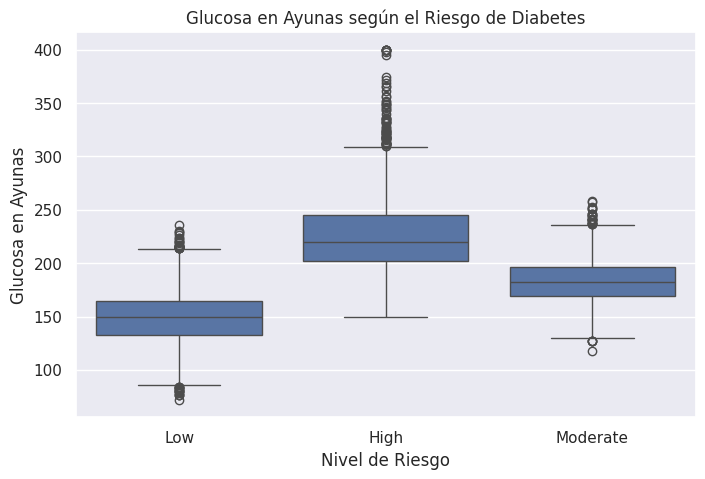

In [11]:
# ==========================================================
# GLUCOSA EN AYUNAS SEGÚN EL RIESGO DE DIABETES
# ==========================================================

# Analizamos cómo varían los niveles de glucosa
# entre los distintos niveles de riesgo.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="fasting_blood_sugar"
)

plt.title("Glucosa en Ayunas según el Riesgo de Diabetes")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Glucosa en Ayunas")

plt.show()

La gráfica evidencia una relación directa entre los niveles de glucosa en ayunas y el riesgo de diabetes. Los pacientes clasificados en la categoría High presentan los valores más elevados de glucosa, con una mediana cercana a los 220 mg/dL, mientras que los pacientes de riesgo Moderate muestran valores intermedios y los pacientes de riesgo Low presentan los niveles más bajos.

Además, se observa que las cajas de las tres categorías se encuentran relativamente separadas, lo que indica que esta variable posee una alta capacidad para diferenciar entre los distintos niveles de riesgo. También existen algunos valores atípicos, especialmente en la categoría High, donde se registran niveles de glucosa considerablemente superiores al promedio.

En general, los resultados sugieren que la variable fasting_blood_sugar es uno de los factores más influyentes en la clasificación del riesgo de diabetes y probablemente tendrá una gran importancia durante el entrenamiento de los modelos predictivos.

**Relación entre HbA1c y el riesgo de diabetes**

La hemoglobina glucosilada (HbA1c) es una prueba utilizada para evaluar el promedio de glucosa en sangre durante los últimos meses. Debido a su importancia clínica en el diagnóstico y seguimiento de la diabetes, se analiza su comportamiento en cada nivel de riesgo con el fin de determinar si existe una relación con la variable objetivo.

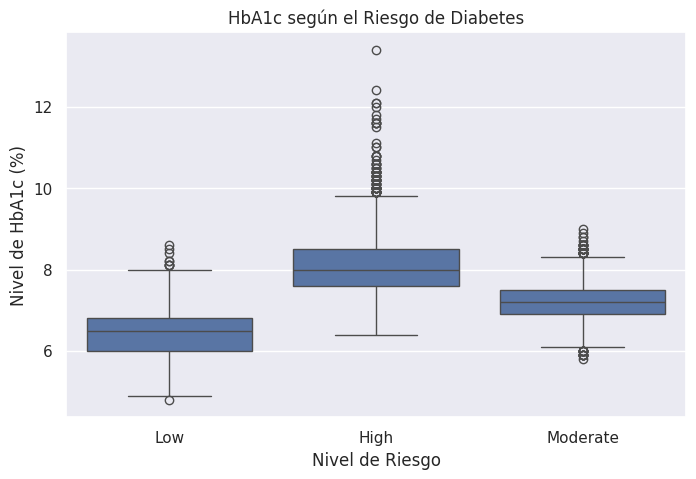

In [12]:
# ==========================================================
# HEMOGLOBINA GLUCOSILADA SEGÚN EL RIESGO DE DIABETES
# ==========================================================

# Analizamos cómo varían los valores de HbA1c
# entre las categorías de riesgo de diabetes.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="hba1c_level"
)

plt.title("HbA1c según el Riesgo de Diabetes")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Nivel de HbA1c (%)")

plt.show()

La gráfica evidencia una relación entre los niveles de HbA1c y el riesgo de diabetes. Los pacientes clasificados en la categoría High presentan los valores más elevados de hemoglobina glucosilada, mientras que los pacientes de riesgo Moderate muestran valores intermedios y los pacientes de riesgo Low presentan los niveles más bajos.

Se observa que la mediana de HbA1c aumenta progresivamente desde la categoría Low hasta la categoría High, lo que indica que niveles más altos de esta variable están asociados con un mayor riesgo de diabetes. Además, existen algunos valores atípicos, especialmente en la categoría High, donde se registran valores considerablemente superiores al promedio.

En general, los resultados sugieren que hba1c_level es una de las variables más importantes para la clasificación del riesgo de diabetes y probablemente tendrá una gran influencia en el desempeño de los modelos predictivos.

**Conclusión del análisis exploratorio realizado**
**BMI**

Existe una tendencia donde los pacientes con mayor riesgo presentan valores más altos de índice de masa corporal.

**fasting_blood_sugar**

Es una de las variables con mejor capacidad de diferenciación entre los niveles de riesgo. A medida que aumenta la glucosa en ayunas, aumenta también el riesgo de diabetes.

**hba1c_level**

Presenta una separación muy clara entre las categorías de riesgo, por lo que probablemente será una de las variables más importantes del modelo.

**Fase de Preprocesamiento**

**Celda: Eliminación de variables innecesarias **

In [13]:
# ==========================================================
# ELIMINACIÓN DE VARIABLES NO RELEVANTES
# ==========================================================

# patient_id únicamente identifica a cada paciente
# pero no aporta información para predecir el riesgo
# de diabetes, por lo que se elimina.

df = df.drop(columns=["patient_id"])

print("Nueva dimensión del dataset:")
print(df.shape)

Nueva dimensión del dataset:
(15000, 18)


La variable patient_id fue eliminada del conjunto de datos debido a que actúa únicamente como identificador único de cada paciente y no aporta información útil para la clasificación del riesgo de diabetes. Mantener este tipo de variables podría introducir ruido en el proceso de entrenamiento de los modelos.

In [14]:
# ==========================================================
# TRATAMIENTO DE VALORES NULOS
# ==========================================================

# Reemplazamos los valores faltantes de las variables
# categóricas por la categoría "Unknown" para evitar
# la pérdida de registros.

df["smoking_status"] = df["smoking_status"].fillna("Unknown")

df["alcohol_consumption"] = df["alcohol_consumption"].fillna("Unknown")

df["income_bracket"] = df["income_bracket"].fillna("Unknown")

# Verificamos nuevamente los valores nulos

df.isnull().sum()

,0
age,0
gender,0
city,0
bmi,0
family_history_diabetes,0
physical_activity_level,0
diet_type,0
smoking_status,0
alcohol_consumption,0
hours_sleep_per_night,0


Se realizó el tratamiento de los valores faltantes presentes en las variables smoking_status, alcohol_consumption e income_bracket mediante la sustitución por la categoría "Unknown". Esta estrategia permitió conservar todos los registros del conjunto de datos sin eliminar información.

Después de aplicar este procedimiento, se verificó que el dataset no presenta valores nulos en ninguna de sus variables, garantizando una adecuada calidad de los datos para las etapas posteriores de modelado y evaluación.

**Fase de Modelado**

In [15]:
# ==========================================================
# SEPARACIÓN DE VARIABLES PREDICTORAS Y VARIABLE OBJETIVO
# ==========================================================

# La variable diabetes_risk será el objetivo (Y)
# que el modelo deberá aprender a predecir.

y = df["diabetes_risk"]

# Las demás variables serán utilizadas para realizar
# las predicciones.

x = df.drop(columns=["diabetes_risk"])

print("Dimensión de X:", x.shape)
print("Dimensión de Y:", y.shape)

Dimensión de X: (15000, 17)
Dimensión de Y: (15000,)


Se separó la variable objetivo (diabetes_risk) del conjunto de variables predictoras. La variable objetivo contiene las categorías de riesgo que el modelo intentará predecir, mientras que el resto de variables proporcionan la información utilizada para realizar dicha predicción.

In [16]:
# ==========================================================
# IDENTIFICACIÓN DE VARIABLES CATEGÓRICAS
# ==========================================================

# Mostramos las variables de tipo texto que deberán
# transformarse a formato numérico.

columnas_texto = x.select_dtypes(include="object").columns.tolist()

print("Variables categóricas:")
print(columnas_texto)

Variables categóricas:
['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']


Los algoritmos de Machine Learning trabajan con datos numéricos. Por esta razón, fue necesario identificar las variables categóricas para posteriormente transformarlas a un formato que pueda ser interpretado por los modelos de clasificación.

In [17]:
# ==========================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ==========================================================

# Transformamos las variables categóricas utilizando
# One-Hot Encoding.

import pandas as pd

x = pd.get_dummies(
    x,
    columns=columnas_texto,
    drop_first=True
)

print("Nueva dimensión del conjunto de datos:")
print(x.shape)

x.head()

Nueva dimensión del conjunto de datos:
(15000, 43)


,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,gender_Male,...,diet_type_Vegetarian,smoking_status_Former,smoking_status_Never,smoking_status_Unknown,alcohol_consumption_Occasional,alcohol_consumption_Regular,alcohol_consumption_Unknown,income_bracket_Low,income_bracket_Middle,income_bracket_Unknown
0,47,26.5,9.0,8,178,7.3,146,90,107.1,False,...,True,False,True,False,False,False,False,False,False,False
1,53,20.5,7.0,6,152,6.9,156,100,93.8,False,...,True,False,True,False,False,False,False,True,False,False
2,47,31.3,7.0,7,168,6.6,150,102,113.5,True,...,False,False,False,False,False,True,False,True,False,False
3,41,22.8,9.0,5,155,6.7,126,92,109.6,True,...,False,False,True,False,False,False,False,False,True,False
4,57,16.7,6.5,10,188,6.7,130,90,80.8,False,...,False,False,False,False,True,False,False,False,False,False


Las variables categóricas fueron transformadas exitosamente mediante la técnica One-Hot Encoding. Como resultado, el número de variables pasó de 17 variables predictoras originales a 43 variables predictoras, ya que cada categoría fue convertida en columnas binarias con valores True y False.

Esta transformación permite que los algoritmos de Machine Learning puedan interpretar correctamente variables como género, ciudad, antecedentes familiares, hábitos alimenticios, actividad física, tabaquismo, consumo de alcohol e ingresos económicos.

Además, se utilizó el parámetro drop_first=True, lo que ayuda a evitar redundancia entre categorías y reduce posibles problemas de multicolinealidad durante el entrenamiento de los modelos.

In [18]:
# ==========================================================
# ESCALAMIENTO DE VARIABLES
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Creamos el escalador
escalador = StandardScaler()

# Ajustamos y transformamos los datos
x_escalado = escalador.fit_transform(x)

print("Dimensión de los datos escalados:")
print(x_escalado.shape)

Dimensión de los datos escalados:
(15000, 43)


Las variables categóricas del conjunto de datos fueron transformadas mediante la técnica One-Hot Encoding, la cual convierte cada categoría de texto en variables numéricas binarias. Como resultado, las 17 variables predictoras originales se expandieron a 43 variables, permitiendo que los algoritmos de Machine Learning procesen correctamente la información. Aunque aumentó el número de columnas, se mantuvieron los mismos 15000 registros del conjunto de datos.

**División de los datos**

In [19]:
# ==========================================================
# DIVISIÓN DE LOS DATOS EN ENTRENAMIENTO Y PRUEBA
# ==========================================================

from sklearn.model_selection import train_test_split

# Dividimos los datos:
# 80% para entrenamiento
# 20% para prueba

X_train, X_test, y_train, y_test = train_test_split(
    x_escalado,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Mostramos las dimensiones obtenidas

print("Datos para entrenamiento:", X_train.shape)
print("Datos para prueba:", X_test.shape)

Datos para entrenamiento: (12000, 43)
Datos para prueba: (3000, 43)


Con el fin de evaluar correctamente el desempeño de los modelos predictivos, el conjunto de datos fue dividido en dos subconjuntos. El 80% de los registros se destinó al entrenamiento de los algoritmos y el 20% restante se reservó para pruebas.

Además, se utilizó el parámetro stratify=y, lo que garantiza que las proporciones de las categorías de riesgo (Low, Moderate y High) se mantengan tanto en el conjunto de entrenamiento como en el de prueba.

In [20]:
# ==========================================================
# MODELOS DE CLASIFICACIÓN
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Definimos los modelos a comparar

modelos = {

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Regresión Logística": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Árbol de Decisión": DecisionTreeClassifier(
        random_state=42
    )
}

print("Modelos cargados correctamente")

Modelos cargados correctamente


Para la clasificación del riesgo de diabetes se seleccionaron tres algoritmos ampliamente utilizados en minería de datos: Regresión Logística, Árbol de Decisión y Random Forest.

La comparación entre estos modelos permitirá identificar cuál ofrece el mejor desempeño para predecir los niveles de riesgo Low, Moderate y High presentes en el conjunto de datos.

In [21]:
# ==========================================================
# COMPARACIÓN DE MODELOS MEDIANTE VALIDACIÓN CRUZADA
# ==========================================================

from sklearn.model_selection import cross_val_score
import pandas as pd

# Diccionario donde almacenaremos los resultados

resultados = {}

for nombre, modelo in modelos.items():

    accuracy = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    resultados[nombre] = accuracy

    print(f"{nombre}: {accuracy:.4f}")

# Creamos una tabla resumen

tabla_resultados = pd.DataFrame(
    resultados.items(),
    columns=["Modelo", "Accuracy"]
)

tabla_resultados.sort_values(
    by="Accuracy",
    ascending=False
)

Random Forest: 0.7910
Regresión Logística: 0.7911
Árbol de Decisión: 0.7128


,Modelo,Accuracy
1,Regresión Logística,0.791083
0,Random Forest,0.791000
2,Árbol de Decisión,0.712833


Se aplicó validación cruzada de cinco bloques para evaluar el rendimiento de los algoritmos seleccionados. Esta técnica divide el conjunto de entrenamiento en cinco partes, utilizando cuatro para entrenar y una para validar en cada iteración.

El objetivo es obtener una estimación más confiable del desempeño de cada modelo antes de seleccionar el algoritmo final.

Comparación de modelos mediante validación cruzada

Se evaluaron tres algoritmos de clasificación utilizando validación cruzada de cinco bloques. Los resultados muestran que la Regresión Logística obtuvo la mejor exactitud promedio con un valor de 79,11%, seguida muy de cerca por Random Forest con 79,10%. Por otro lado, el Árbol de Decisión alcanzó una exactitud de 71,28%, presentando un rendimiento inferior respecto a los demás modelos.

Los resultados indican que tanto la Regresión Logística como Random Forest poseen una capacidad adecuada para clasificar los niveles de riesgo de diabetes. Debido a que la Regresión Logística obtuvo el mejor desempeño, será seleccionada como modelo principal para las siguientes etapas de evaluación y predicción.

In [22]:
# ==========================================================
# ENTRENAMIENTO DEL MODELO FINAL
# ==========================================================

from sklearn.linear_model import LogisticRegression

# Entrenamos el modelo que obtuvo
# el mejor resultado en la validación cruzada.

modelo_final = LogisticRegression(
    max_iter=2000,
    random_state=42
)

modelo_final.fit(
    X_train,
    y_train
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


**Entrenamiento del modelo final**

Una vez comparados los diferentes algoritmos, se seleccionó la Regresión Logística como modelo final debido a que obtuvo la mejor exactitud durante la validación cruzada. Posteriormente, el modelo fue entrenado utilizando todos los datos del conjunto de entrenamiento para maximizar su capacidad de aprendizaje.

In [23]:
# ==========================================================
# PREDICCIONES SOBRE DATOS NO VISTOS
# ==========================================================

# El modelo realiza predicciones
# sobre el conjunto de prueba.

predicciones = modelo_final.predict(X_test)

print("Cantidad de predicciones realizadas:")
print(len(predicciones))

Cantidad de predicciones realizadas:
3000


In [24]:
# ==========================================================
# EVALUACIÓN DEL MODELO
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    predicciones
)

print(f"Accuracy final: {accuracy:.4f}")

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        predicciones
    )
)

Accuracy final: 0.7937

Reporte de clasificación:
              precision    recall  f1-score   support

        High       0.82      0.72      0.77       450
         Low       0.86      0.91      0.88      1800
    Moderate       0.60      0.56      0.58       750

    accuracy                           0.79      3000
   macro avg       0.76      0.73      0.74      3000
weighted avg       0.79      0.79      0.79      3000



Evaluación del modelo

Para evaluar el rendimiento del modelo se utilizó el conjunto de prueba, compuesto por datos que no fueron observados durante el entrenamiento.

Las métricas obtenidas permiten medir el desempeño del modelo en la clasificación de los distintos niveles de riesgo de diabetes y determinar su capacidad de generalización frente a nuevos casos.

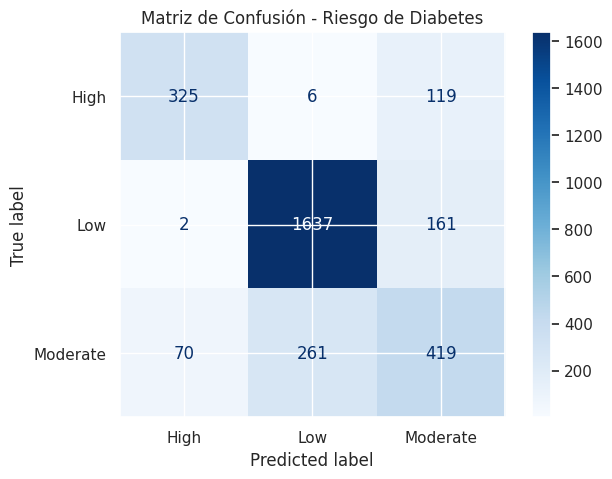

In [25]:
# ==========================================================
# MATRIZ DE CONFUSIÓN
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones,
    cmap="Blues",
    ax=ax
)

ax.set_title(
    "Matriz de Confusión - Riesgo de Diabetes"
)

plt.show()


La matriz de confusión permite visualizar cuántas predicciones fueron correctas y cuántas fueron clasificadas incorrectamente por el modelo. Esta representación facilita la identificación de posibles errores entre las categorías Low, Moderate y High.

**Evaluación del desempeño del modelo**

El modelo de Regresión Logística obtuvo una exactitud (Accuracy) de 79,37% al ser evaluado con el conjunto de prueba. Esto significa que aproximadamente 8 de cada 10 pacientes fueron clasificados correctamente en su respectivo nivel de riesgo de diabetes.

Además, las métricas de precisión, recall y F1-score muestran que el modelo presenta un mejor desempeño en las categorías Low y High, mientras que la categoría Moderate resulta más difícil de identificar correctamente debido a que comparte características con las otras dos categorías.

En general, los resultados obtenidos indican que el modelo posee una capacidad adecuada para clasificar el riesgo de diabetes y puede utilizarse como base para desarrollar un sistema de apoyo en la predicción de nuevos pacientes.

**Análisis de la matriz de confusión**

La matriz de confusión permite observar la cantidad de clasificaciones correctas e incorrectas realizadas por el modelo.

Se puede apreciar que:

1637 pacientes con riesgo Low fueron clasificados correctamente.
419 pacientes con riesgo Moderate fueron clasificados correctamente.
325 pacientes con riesgo High fueron clasificados correctamente.

Los principales errores se presentan entre las categorías Moderate y Low, donde varios pacientes fueron confundidos debido a la similitud de sus características médicas y hábitos de vida.

A pesar de estas confusiones, el modelo logra diferenciar adecuadamente la mayoría de los casos, obteniendo una exactitud global cercana al 80%.

In [26]:
# ==========================================================
# IMPORTANCIA DE VARIABLES
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculamos la importancia usando el valor absoluto
# de los coeficientes de la regresión logística

importancia = np.abs(modelo_final.coef_).mean(axis=0)

variables_importantes = pd.DataFrame({
    "Variable": x.columns,
    "Importancia": importancia
})

variables_importantes = variables_importantes.sort_values(
    by="Importancia",
    ascending=False
)

variables_importantes.head(10)


,Variable,Importancia
4,fasting_blood_sugar,1.242257
5,hba1c_level,0.971603
0,age,0.453631
1,bmi,0.294023
28,family_history_diabetes_Yes,0.167101
18,city_Kanpur,0.050358
19,city_Kolkata,0.048710
8,waist_circumference_cm,0.047938
29,physical_activity_level_Moderate,0.047305
39,alcohol_consumption_Unknown,0.044481


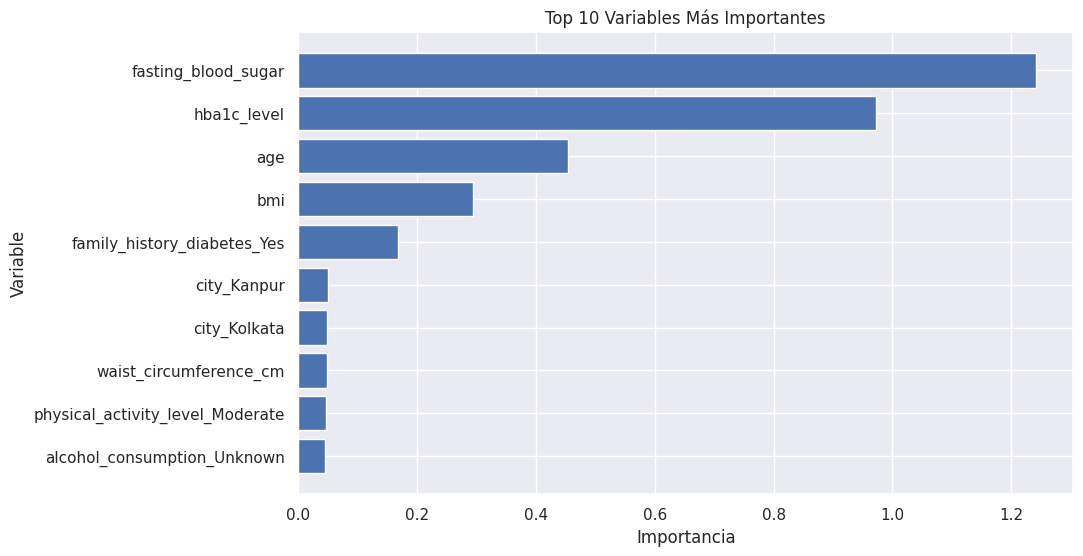

In [27]:
# ==========================================================
# TOP 10 VARIABLES MÁS IMPORTANTES
# ==========================================================

top10 = variables_importantes.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Variable"],
    top10["Importancia"]
)

plt.title("Top 10 Variables Más Importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.gca().invert_yaxis()

plt.show()

El análisis de importancia de variables permitió identificar los factores que tienen mayor influencia en la clasificación del riesgo de diabetes. Los resultados muestran que fasting_blood_sugar (glucosa en ayunas) es la variable con mayor impacto en el modelo, seguida por hba1c_level (hemoglobina glucosilada), age (edad) y bmi (índice de masa corporal).

Además, los antecedentes familiares de diabetes (family_history_diabetes_Yes) también presentan una contribución importante en la clasificación del riesgo. Estos resultados son consistentes con el conocimiento médico, ya que niveles elevados de glucosa, hemoglobina glucosilada, mayor edad y sobrepeso son factores ampliamente asociados al desarrollo de diabetes.

En general, el modelo confirma que las variables clínicas poseen una mayor influencia que las variables demográficas o socioeconómicas en la determinación del riesgo de diabetes.

**Conclusiones**

Se desarrolló un modelo de minería de datos orientado a la clasificación del riesgo de diabetes utilizando un conjunto de datos compuesto por 15000 pacientes y variables relacionadas con características demográficas, hábitos de vida y factores clínicos.

Durante la fase de exploración se identificaron valores faltantes en algunas variables categóricas, los cuales fueron tratados adecuadamente para garantizar la calidad de los datos. Posteriormente, se aplicaron técnicas de transformación y estandarización para preparar la información para los algoritmos de aprendizaje automático.

La comparación entre distintos algoritmos mostró que la Regresión Logística obtuvo el mejor desempeño con una exactitud aproximada del 79,37%, superando ligeramente a Random Forest y logrando resultados satisfactorios para la clasificación de los niveles de riesgo Low, Moderate y High.

Finalmente, el análisis de importancia de variables permitió determinar que la glucosa en ayunas, la hemoglobina glucosilada, la edad y el índice de masa corporal son los factores más relevantes para la predicción del riesgo de diabetes.

**Recomendaciones**

Incorporar nuevas variables clínicas para mejorar la capacidad predictiva del modelo.
Evaluar algoritmos más avanzados como XGBoost o Gradient Boosting.
Aplicar técnicas de balanceo de clases para mejorar la clasificación de la categoría Moderate.
Implementar una API REST que permita realizar predicciones en tiempo real a partir de los datos ingresados por un usuario.
Integrar el modelo en una aplicación web para facilitar su uso en entornos académicos o de apoyo a la toma de decisiones.

**Guardamos modelo entrenado**

In [28]:
# ==========================================================
# GUARDAR MODELO ENTRENADO
# ==========================================================

# La librería joblib permite guardar modelos
# de Machine Learning para utilizarlos posteriormente.

import joblib

# Guardamos el modelo entrenado
joblib.dump(modelo_final, "modelo_diabetes.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [29]:
# ==========================================================
# VERIFICACIÓN DEL MODELO GUARDADO
# ==========================================================

modelo_cargado = joblib.load("modelo_diabetes.pkl")

print(type(modelo_cargado))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


Una vez finalizado el entrenamiento, el modelo de Regresión Logística fue almacenado en un archivo con extensión .pkl. Este archivo contiene los parámetros aprendidos durante el proceso de entrenamiento y permitirá reutilizar el modelo sin necesidad de volver a entrenarlo.

El modelo almacenado será utilizado posteriormente por una API REST para realizar predicciones sobre nuevos pacientes ingresados por los usuarios.

In [30]:
# ==========================================================
# GUARDAR EL ESCALADOR
# ==========================================================

joblib.dump(escalador, "escalador.pkl")

print("Escalador guardado correctamente")

Escalador guardado correctamente


Se guardó también el objeto de estandarización (StandardScaler) utilizado durante el preprocesamiento. Esto garantiza que los nuevos datos ingresados en la API sean transformados exactamente de la misma manera que los datos utilizados durante el entrenamiento.

In [31]:
# ==========================================================
# GUARDAR ESTRUCTURA DE COLUMNAS
# ==========================================================

joblib.dump(
    x.columns.tolist(),
    "columnas_modelo.pkl"
)

print("Columnas guardadas correctamente")

Columnas guardadas correctamente


Se almacenó la lista de variables utilizadas por el modelo después del proceso de codificación categórica. Esto permitirá reconstruir correctamente la estructura esperada por el algoritmo cuando se realicen predicciones mediante la API.

